
================ TASK 1: CUSTOMER SEGMENTATION USING K-MEANS ================

Dataset Overview:
Shape of dataset: (200, 4)
   customer_id  age  income  spending_score
0            1   45   57155              10
1            2   38   61215              35
2            3   47   71661              50
3            4   58   71076              51
4            5   37   22446              38

================ CLUSTERING WITHOUT FEATURE SCALING ================
Model Evaluation (Without Scaling):
Silhouette Score: 0.5482

Cluster Centers (Without Scaling):
[[3.74266667e+01 3.26908667e+04 5.00533333e+01]
 [3.99042553e+01 5.73424468e+04 4.47659574e+01]
 [4.08064516e+01 8.22763871e+04 4.86774194e+01]]

================ CLUSTERING WITH FEATURE SCALING (AGE EXCLUDED) ================
Model Evaluation (With Scaling):
Silhouette Score: 0.5142

Cluster Centers (With Scaling):
[[ 5.43809524e+01 -7.96443764e-03 -1.38926410e-01]
 [ 2.66984127e+01 -2.00261109e-01  1.39436135e-01]
 [ 4.06000000e+01  1.363

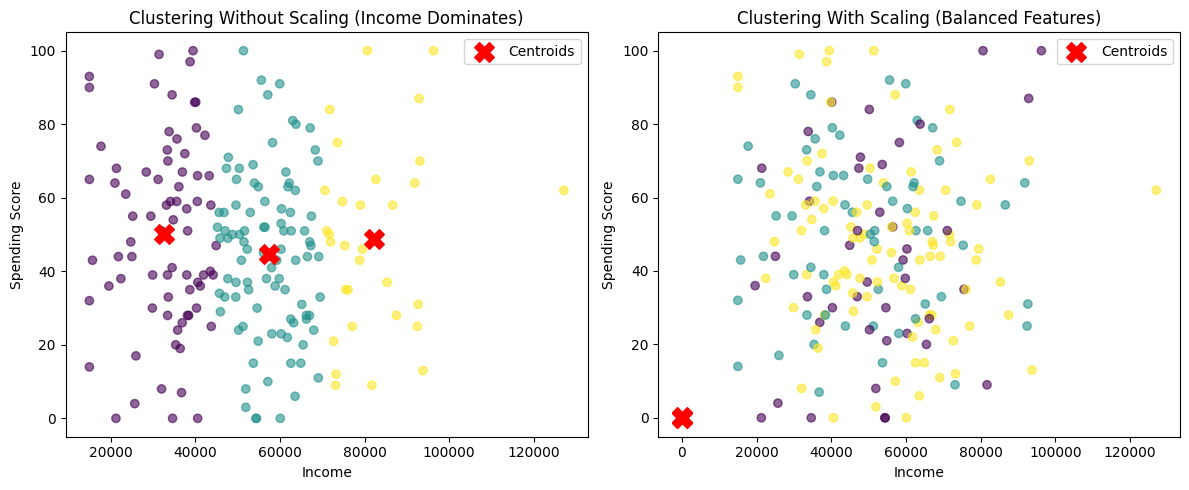


================ INSIGHTS AND INTERPRETATION ================
Observation: Clustering without scaling produced better separation.
Insight 1: Without scaling, income dominates clustering due to its large numeric range.
Insight 2: With scaling, income and spending_score contribute equally to distance calculations.
Insight 3: Age remains unscaled as required, preserving its original distribution.
Insight 4: Cluster assignments change after scaling, showing sensitivity of K-Means to feature magnitude.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("\n================ TASK 1: CUSTOMER SEGMENTATION USING K-MEANS ================")

np.random.seed(42)
n_samples = 200

df = pd.DataFrame({
    "customer_id": range(1, n_samples + 1),
    "age": np.random.normal(40, 12, n_samples).clip(18, 80).astype(int),
    "income": np.random.normal(50000, 20000, n_samples).clip(15000, 150000).astype(int),
    "spending_score": np.random.normal(50, 25, n_samples).clip(0, 100).astype(int)
})

print("\nDataset Overview:")
print("Shape of dataset:", df.shape)
print(df.head())

# FEATURE SELECTION
X = df.drop("customer_id", axis=1)


# CLUSTERING WITHOUT SCALING

print("\n================ CLUSTERING WITHOUT FEATURE SCALING ================")

kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_raw"] = kmeans_raw.fit_predict(X)

silhouette_raw = silhouette_score(X, df["cluster_raw"])

print("Model Evaluation (Without Scaling):")
print(f"Silhouette Score: {silhouette_raw:.4f}")

print("\nCluster Centers (Without Scaling):")
print(kmeans_raw.cluster_centers_)


# CLUSTERING WITH SCALING (AGE EXCLUDED)
print("\n================ CLUSTERING WITH FEATURE SCALING (AGE EXCLUDED) ================")

X_scaled = X.copy()

scaler = StandardScaler()
X_scaled[["income", "spending_score"]] = scaler.fit_transform(
    X_scaled[["income", "spending_score"]]
)

kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_scaled"] = kmeans_scaled.fit_predict(X_scaled)

silhouette_scaled = silhouette_score(X_scaled, df["cluster_scaled"])

print("Model Evaluation (With Scaling):")
print(f"Silhouette Score: {silhouette_scaled:.4f}")

print("\nCluster Centers (With Scaling):")
print(kmeans_scaled.cluster_centers_)


# COMPARISON
print("\n================ CLUSTERING COMPARISON SUMMARY ================")

print(f"Silhouette Score (Without Scaling): {silhouette_raw:.4f}")
print(f"Silhouette Score (With Scaling): {silhouette_scaled:.4f}")

changed = df["cluster_raw"].ne(df["cluster_scaled"]).sum()

print("\nCluster Change Analysis:")
print(f"Number of customers that changed cluster after scaling: {changed} out of {len(df)}")

print("\nCross-Cluster Mapping (Raw vs Scaled):")
print(pd.crosstab(df["cluster_raw"], df["cluster_scaled"], margins=True))


# VISUALIZATION

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# WITHOUT SCALING
axes[0].scatter(df["income"], df["spending_score"],c=df["cluster_raw"], cmap="viridis", alpha=0.6)
axes[0].set_title("Clustering Without Scaling (Income Dominates)")
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Spending Score")
axes[0].scatter(kmeans_raw.cluster_centers_[:, 1], kmeans_raw.cluster_centers_[:, 2], c="red", marker="X", s=200, label="Centroids")
axes[0].legend()

# WITH SCALING
axes[1].scatter(df["income"], df["spending_score"],c=df["cluster_scaled"], cmap="viridis", alpha=0.6)
axes[1].set_title("Clustering With Scaling (Balanced Features)")
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Spending Score")
axes[1].scatter(kmeans_scaled.cluster_centers_[:, 1], kmeans_scaled.cluster_centers_[:, 2], c="red", marker="X", s=200, label="Centroids")
axes[1].legend()

plt.tight_layout()
plt.show()


print("\n================ INSIGHTS AND INTERPRETATION ================")

if silhouette_scaled > silhouette_raw:
    print("Observation: Feature scaling improved clustering quality (higher silhouette score).")
else:
    print("Observation: Clustering without scaling produced better separation.")

print("Insight 1: Without scaling, income dominates clustering due to its large numeric range.")
print("Insight 2: With scaling, income and spending_score contribute equally to distance calculations.")
print("Insight 3: Age remains unscaled as required, preserving its original distribution.")
print("Insight 4: Cluster assignments change after scaling, showing sensitivity of K-Means to feature magnitude.")


FINAL DATA WITH CLUSTERS:
   vehicle_serial_no  Cluster_No_Scale  Cluster_Scaled
0                  5                 2               2
1                  3                 0               0
2                  8                 1               1
3                  2                 0               0
4                  4                 0               0
5                  7                 2               1
6                  6                 2               2
7                 10                 1               1
8                  1                 0               0
9                  9                 1               2


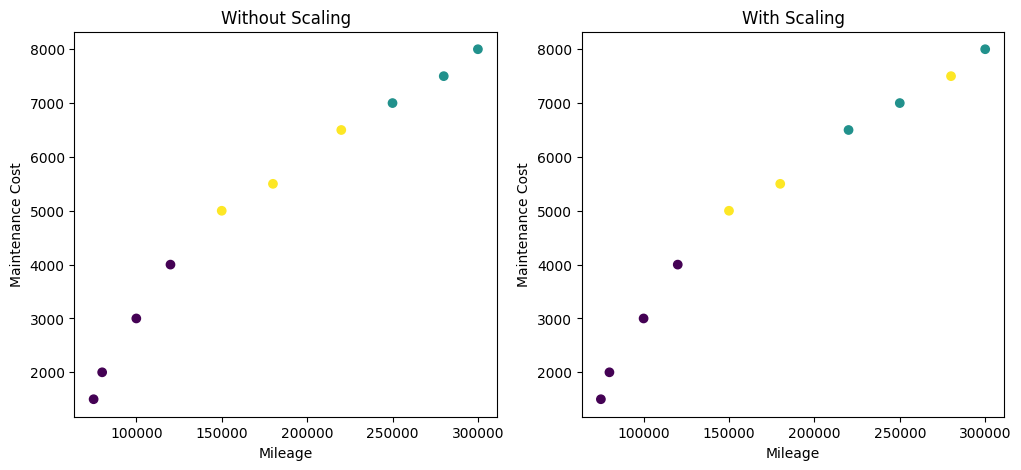

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan',
                     'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}

df = pd.DataFrame(data)
 
# ENCODING CATEGORICAL DATA 
df_encoded = pd.get_dummies(df, columns=['vehicle_type'], drop_first=True)

# REMOVE ID COLUMN
X = df_encoded.drop(columns=['vehicle_serial_no'])

# 1. K-MEANS WITHOUT SCALING 
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_raw = kmeans_raw.fit_predict(X)

# 2. K-MEANS WITH SCALING 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_scaled = kmeans_scaled.fit_predict(X_scaled)

# ADD CLUSTERS TO DATAFRAME 
df['Cluster_No_Scale'] = clusters_raw
df['Cluster_Scaled'] = clusters_scaled

print("\nFINAL DATA WITH CLUSTERS:")
print(df[['vehicle_serial_no', 'Cluster_No_Scale', 'Cluster_Scaled']])

# VISUALIZATION (Mileage vs Maintenance Cost)
plt.figure(figsize=(12,5))

# WITHOUT SCALING
plt.subplot(1,2,1)
plt.scatter(df['mileage'], df['maintenance_cost'], c=clusters_raw)
plt.title("Without Scaling")
plt.xlabel("Mileage")
plt.ylabel("Maintenance Cost")

# WITH SCALING
plt.subplot(1,2,2)
plt.scatter(df['mileage'], df['maintenance_cost'], c=clusters_scaled)
plt.title("With Scaling")
plt.xlabel("Mileage")
plt.ylabel("Maintenance Cost")

plt.show()

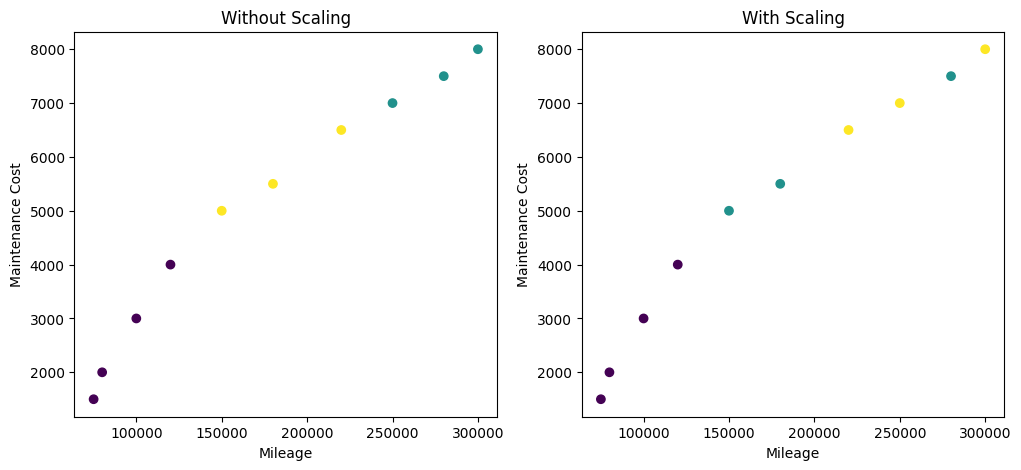

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan',
                     'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}

df = pd.DataFrame(data)
 
# ENCODING
df_encoded = pd.get_dummies(df, columns=['vehicle_type'])

# REMOVE ID COLUMN
X = df_encoded.drop(columns=['vehicle_serial_no'])
 
# KMEANS WITHOUT SCALING
k1 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_raw = k1.fit_predict(X)
 
# SCALING 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMEANS WITH SCALING 
k2 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_scaled = k2.fit_predict(X_scaled)

# VISUALIZATION 
plt.figure(figsize=(12,5))

# WITHOUT SCALING
plt.subplot(1,2,1)
plt.scatter(df['mileage'], df['maintenance_cost'], c=clusters_raw)
plt.title("Without Scaling")
plt.xlabel("Mileage")
plt.ylabel("Maintenance Cost")

# WITH SCALING
plt.subplot(1,2,2)
plt.scatter(df['mileage'], df['maintenance_cost'], c=clusters_scaled)
plt.title("With Scaling")
plt.xlabel("Mileage")
plt.ylabel("Maintenance Cost")

plt.show()

Data:
   student_id   GPA  study_hours  attendance_rate
0          25  4.00           70              0.3
1          40  2.80           40              0.7
2          35  3.60           65              0.8
3          28  3.45           90              0.9
4          45  3.90           55              0.5

Shape: (6, 4)


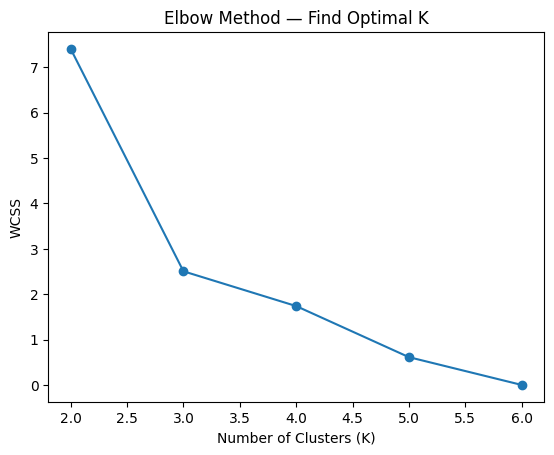

Data with cluster labels:     student_id   GPA  study_hours  attendance_rate  Cluster
0          25  4.00           70             0.30        2
1          40  2.80           40             0.70        1
2          35  3.60           65             0.80        0
3          28  3.45           90             0.90        0
4          45  3.90           55             0.50        2
5          22  2.74           20             0.98        1


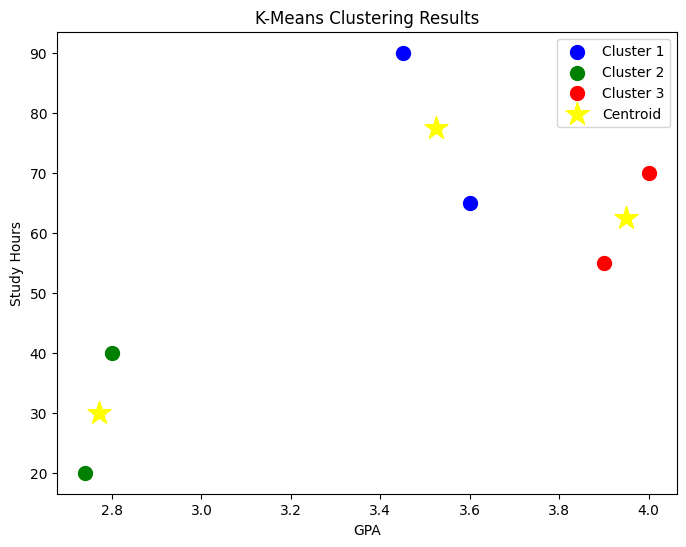

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'student_id':    [25, 40, 35, 28, 45, 22],
    'GPA': [4, 2.8, 3.6, 3.45, 3.9, 2.74],
    'study_hours': [70, 40, 65, 90, 55, 20],
    'attendance_rate' : [0.3,0.7,0.8,0.9,0.5,0.98]
}
df = pd.DataFrame(data)   # convert dictionary to a table

print("Data:")
print(df.head())           # show first 5 rows
print("\nShape:", df.shape) # (rows, columns)

X = df[['GPA', 'study_hours', 'attendance_rate']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # learn scale and apply it


wcss_list = []   # empty list to store WCSS for each K

for i in range(2,7):                        # try K from 1 to 10
    kmeans = KMeans(
        n_clusters=i,                         # number of clusters
        init='k-means++',                     # smart centroid initialization
        random_state=42                       # fixed seed for reproducibility
    )
    kmeans.fit(X_scaled)                      # run clustering
    wcss_list.append(kmeans.inertia_)         # inertia = WCSS score

# Plot the Elbow Graph
plt.plot(range(2,7), wcss_list, marker='o')
plt.title('Elbow Method — Find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

K = 3   # <-- change this based on what the elbow graph shows

kmeans = KMeans(
    n_clusters=K,          # number of clusters you want
    init='k-means++',      # better starting centroids (avoids bad results)
    random_state=42        # same seed = same results every run
)

y_predict = kmeans.fit_predict(X_scaled)
df['Cluster'] = y_predict
print("Data with cluster labels: ", df)

# VISUALIZE CLUSTERS (2D Scatter Plot)
plt.figure(figsize=(8,6))

colors = ['blue', 'green', 'red', 'black', 'purple', 'orange']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5', 'Cluster 6']

for i in range(K):
    plt.scatter(X[y_predict == i, 0], X[y_predict == i, 1], s=100, color=colors[i], label=labels[i])

# Plot centroids (center of each cluster) — on original scale
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], s=300, c='yellow', marker='*',  label='Centroid')

plt.title('K-Means Clustering Results')
plt.xlabel('GPA')                 # change to your x feature name
plt.ylabel('Study Hours')              # change to your y feature name
plt.legend()
plt.show()


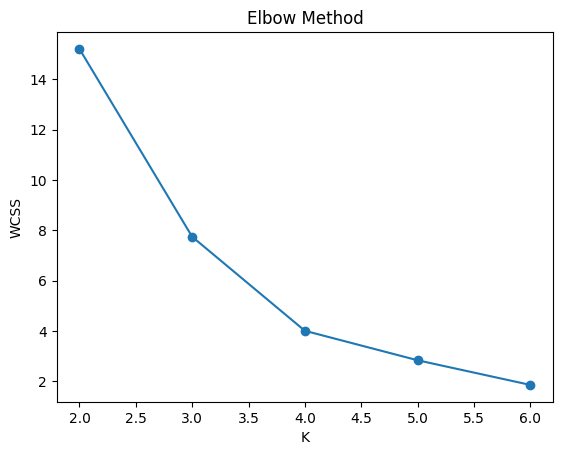


FINAL DATA WITH CLUSTERS:
   student_id  Cluster
0          25        2
1          40        1
2          35        0
3          28        0
4          45        2
5          22        1
6          31        1
7          38        0
8          41        1
9          29        0


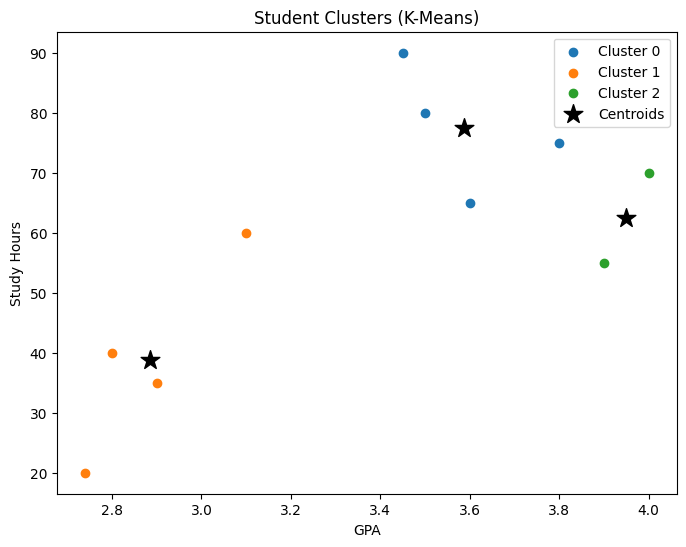

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'student_id': [25, 40, 35, 28, 45, 22, 31, 38, 41, 29],
    'GPA': [4, 2.8, 3.6, 3.45, 3.9, 2.74, 3.1, 3.8, 2.9, 3.5],
    'study_hours': [70, 40, 65, 90, 55, 20, 60, 75, 35, 80],
    'attendance_rate': [0.3, 0.7, 0.8, 0.9, 0.5, 0.98, 0.6, 0.85, 0.4, 0.95]
}

df = pd.DataFrame(data)

# FEATURES 
X = df[['GPA', 'study_hours', 'attendance_rate']]

# SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
# ELBOW METHOD
wcss = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 7), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

# FINAL K (assume elbow = 3)
K = 3

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nFINAL DATA WITH CLUSTERS:")
print(df[['student_id', 'Cluster']])

 
# VISUALIZATION (GPA vs Study Hours) 
plt.figure(figsize=(8,6))

for i in range(K):
    plt.scatter(
        df[df['Cluster'] == i]['GPA'],
        df[df['Cluster'] == i]['study_hours'],
        label=f'Cluster {i}'
    )

centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=200,
    marker='*',
    color='black',
    label='Centroids'
)

plt.title("Student Clusters (K-Means)")
plt.xlabel("GPA")
plt.ylabel("Study Hours")
plt.legend()
plt.show()